In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

def last_noNaN_index(serie):
    return((~np.isnan(serie.flatten())).cumsum(0).argmax(0))

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def forward_sequence_1dim(vrae_model, sequence):
    if sequence.shape[0]>vrae_model.sequence_length:
        print(f'Sequence not {vrae_model.sequence_length}')
        return(-1)
    vrae_model.eval()
    fake_batch_200 = np.tile(sequence, (200, 1)).T
    fake_batch_200 = torch.from_numpy(fake_batch_200).float().unsqueeze(2).cuda()
    reconstruction = vrae_model.forward(fake_batch_200)
    return reconstruction[0][:,0,:].cpu().detach().numpy()

# df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
# df_tracks= df.pivot(values=[
#     'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
#     'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
#     'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
#     'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
#     'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
#     'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
#     index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
#     columns='Time')

X_train shape	 (32635, 96, 1) 	 X_test shape	 (3627, 96, 1)


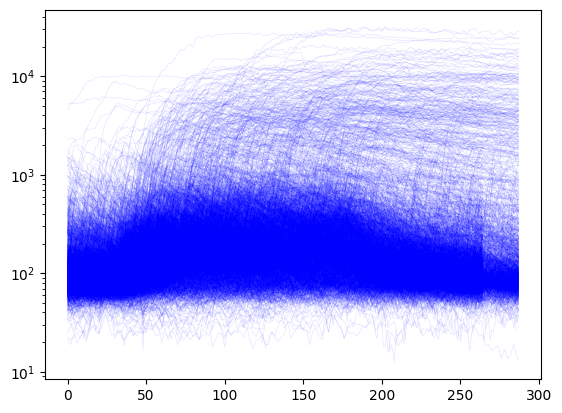

In [ ]:
### Creating dataset and splitting it into train and test sets then data augmentation
# liste_x=[]
# liste_y=[]

# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']

# for exp_name in dataset_name_list:

#     medium,treatment,replicate = exp_name.split('_')

#     frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
#     size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
#     cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
#     sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
#     mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

#     DeathSubtype = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])

#     for i in range(size_array.shape[0]):
#         ##fill nans missing timepoints with the mean of the previous and next timepoints
#         size_serie =  size_array[i]
#         for j in range(1,len(size_serie)-1):
#             if np.isnan(size_serie[j]):
#                 size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

#         sos_serie = sos_array[i]
#         for j in range(1,len(sos_serie)-1):
#             if np.isnan(sos_serie[j]):
#                 sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
#         mcherry_serie = mcherry_array[i]
#         for j in range(1,len(mcherry_serie)-1):
#             if np.isnan(mcherry_serie[j]):
#                 mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

#         cyclefate_serie = cyclefate_array[i]
#         for j in range(len(cyclefate_serie)-1):
#             if cyclefate_serie[j] == 'nan':
#                 cyclefate_serie[j] = cyclefate_serie[j+1]

#         t_death = len(cyclefate_serie)
#         if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
#             t_death = np.where(cyclefate_serie != 'alive')[0][0]

#         # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
#         first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

#         if first_NaN>96:
#             last_usable_timepoint = min(first_NaN,288)
#             liste_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
#             liste_y.append((medium,treatment,replicate,t_death,DeathSubtype[i]))
# #scan for NANs in all liste_x
# for x in liste_x:
#     for serie in x:
#         if np.sum(np.isnan(serie))>0:
#             print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',np.array(liste_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',np.array(liste_y,dtype=object))

liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',allow_pickle=True)

liste_x_scaled = my_scaler([x[1] for x in liste_x], feature_range=(-1,1)) #using only the SOS signal

liste_x_train = []
liste_y_train = []
for i in range(len(liste_x_scaled)):
    usable_data = liste_x_scaled[i]
    for j in range(0, len(usable_data) - 96 + 1, 12):
        liste_x_train.append(usable_data[j:j+96])
        liste_y_train.append(liste_y[i])

X_train, X_test, y_train, y_test = train_test_split(np.array(liste_x_train)[:,:,np.newaxis], np.array(liste_y_train), test_size=0.1, random_state=42, shuffle=False)

train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

for s  in  [x[1] for x in liste_x]:
    plt.plot(s,alpha=0.1,color='blue',linewidth=0.5)
plt.yscale('log')

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

In [ ]:
## training cell
replicate = 2
t0 = time.time()

sequence_length = X_train.shape[1]

number_of_features = 1
dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU


for latent_length in range(20,2-1,-1):
    print('latent_length\t',latent_length,'\t elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

    vrae = VRAE(sequence_length=sequence_length,
                number_of_features = number_of_features,
                hidden_size = hidden_size, 
                hidden_layer_depth = hidden_layer_depth,
                latent_length = latent_length,
                batch_size = batch_size,
                learning_rate = learning_rate,
                n_epochs = n_epochs,
                dropout_rate = dropout_rate,
                optimizer = optimizer, 
                cuda = cuda,
                print_every=print_every, 
                clip=clip, 
                max_grad_norm=max_grad_norm,
                loss = loss,
                block = block,
                dload = dload)

    vrae.fit(train_dataset, test_dataset, save=True)

    file = open(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\print.txt').readlines()
    train_losses = []
    test_losses = []
    for line in file:
        if 'Average loss' in line:
            train_losses.append(float(line.split(' ')[-2]))
            test_losses.append(float(line.split(' ')[-1][:-2]))
            # print(float(line.split(' ')[-2]),float(line.split(' ')[-1][:-2]))

    shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\model_{replicate}_{latent_length}.pth')
    shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model_best.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\model_best_{replicate}_{latent_length}.pth')
    np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\train_losses_{replicate}_{latent_length}.npy', train_losses)
    np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\test_losses_{replicate}_{latent_length}.npy', test_losses)
### 251m 

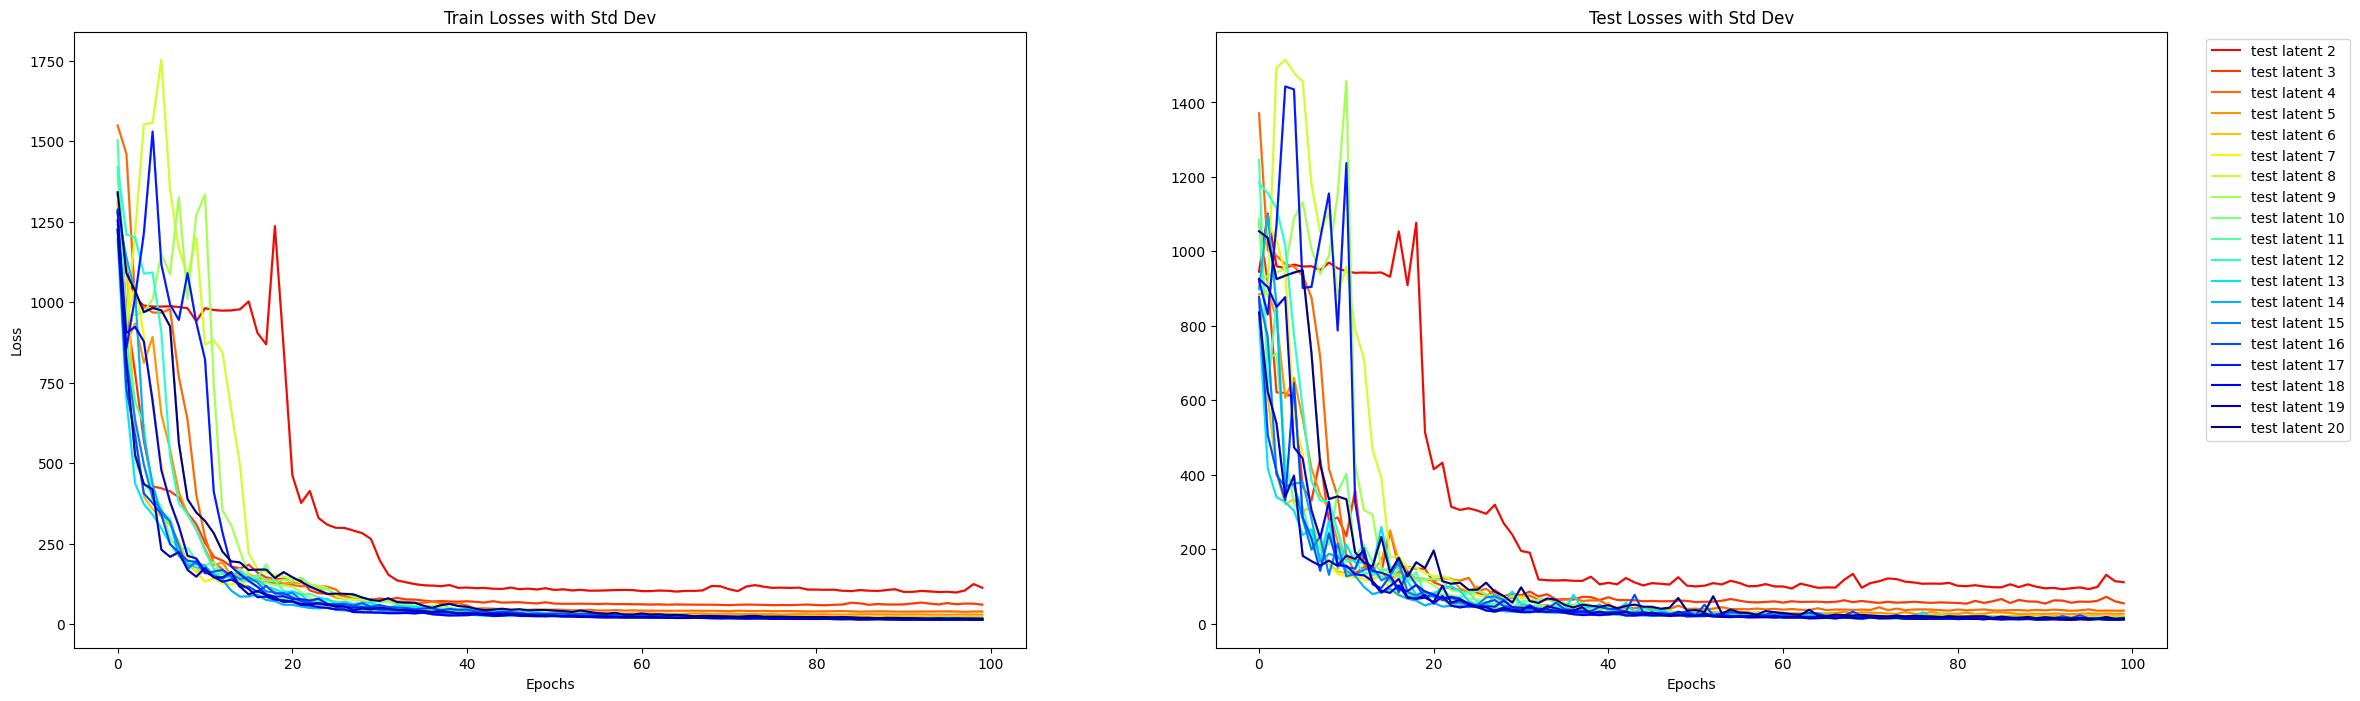

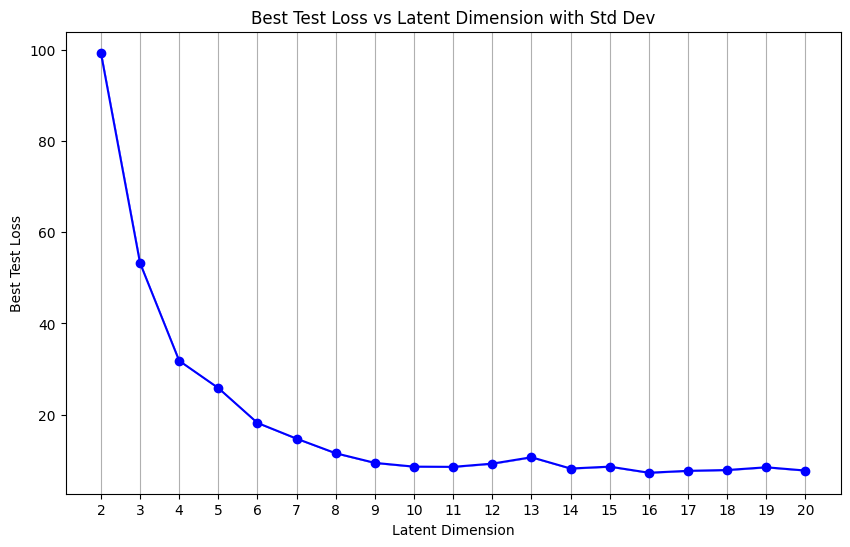

In [3]:
## trainig curves
plot_until_epoch = 100
n_replicate = 1
path=fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom'
loss_dict = {}
for latent_length in range(2, 21):
    loss_dict[latent_length] = ([],[])
    for replicate in range(n_replicate):
        train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
        test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
        loss_dict[latent_length][0].append(train_losses)
        loss_dict[latent_length][1].append(test_losses)

# plot mean train loss and mean test loss with std curves+fill as a function of latent dimension using loss_dict 
mean_train_losses = np.zeros((19,200))
mean_test_losses = np.zeros((19,200))
std_train_losses = np.zeros((19,200))
std_test_losses = np.zeros((19,200))

for latent_length in range(2, 21):
    mean_train_losses[latent_length-2] = np.mean(loss_dict[latent_length][0], axis=0)
    mean_test_losses[latent_length-2] = np.mean(loss_dict[latent_length][1], axis=0)
    std_train_losses[latent_length-2] = np.std(loss_dict[latent_length][0], axis=0)
    std_test_losses[latent_length-2] = np.std(loss_dict[latent_length][1], axis=0)

fig,ax = plt.subplots(1,2,figsize=(27,8))
cmap = plt.get_cmap('jet')
for latent_length in range(2, 21):
    ax[0].plot(mean_train_losses[latent_length-2,:plot_until_epoch], label=f'train latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[0].fill_between(range(plot_until_epoch), 
                       mean_train_losses[latent_length-2,:plot_until_epoch]-std_train_losses[latent_length-2,:plot_until_epoch], 
                       mean_train_losses[latent_length-2,:plot_until_epoch]+std_train_losses[latent_length-2,:plot_until_epoch], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[1].plot(mean_test_losses[latent_length-2,:plot_until_epoch], label=f'test latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[1].fill_between(range(plot_until_epoch), 
                       mean_test_losses[latent_length-2,:plot_until_epoch]-std_test_losses[latent_length-2,:plot_until_epoch], 
                       mean_test_losses[latent_length-2,:plot_until_epoch]+std_test_losses[latent_length-2,:plot_until_epoch], 
                       color=cmap((20-latent_length)/20), alpha=0.3)
    ax[0].set_title('Train Losses with Std Dev')
    ax[1].set_title('Test Losses with Std Dev')
    ax[0].set_xlabel('Epochs')
    ax[1].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# plot best test loss with std curves+fill as a function of latent dimension
std_test_losses = []
best_test_loss = []
for latent_length in range(2, 21):
    test_losses = loss_dict[latent_length][1]
    best_losses = np.min(np.array(test_losses)[:,-1])
    std_loss = np.std(np.array(test_losses)[:,-1])
    best_test_loss.append(best_losses)
    std_test_losses.append(std_loss)
plt.figure(figsize=(10,6))
plt.plot(range(2, 21), best_test_loss, marker='o', label='Best Test Loss', color='blue')
plt.fill_between(range(2, 21), 
                 np.array(best_test_loss)-np.array(std_test_losses), 
                 np.array(best_test_loss)+np.array(std_test_losses), 
                 color='blue', alpha=0.3, label='Std Dev')
plt.xticks(range(2, 21))
plt.title('Best Test Loss vs Latent Dimension with Std Dev')
plt.xlabel('Latent Dimension')
plt.ylabel('Best Test Loss')
plt.grid(axis='x')

best_replicate_15 = np.argmin([arr[-1] for arr in loss_dict[15][1]]) #3

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.



torch.Size([96, 200, 1])
160


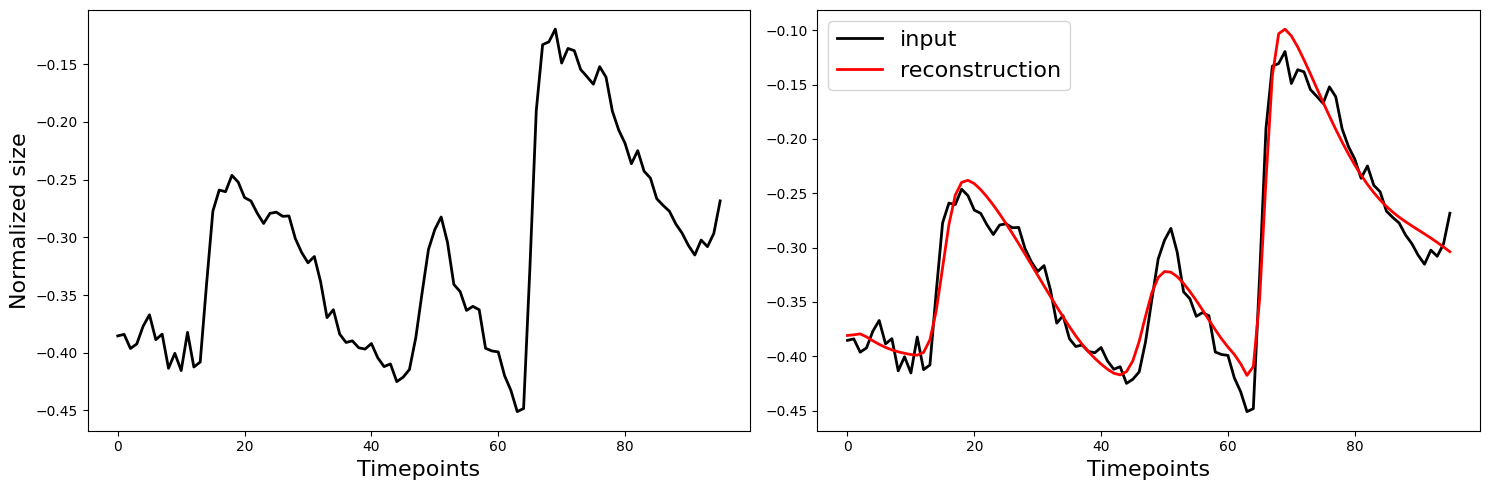

In [4]:
## load model 10 0
sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_save' #model save directory
latent_length = 15
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001
n_epochs = 2 #200
dropout_rate = 0.2
optimizer = 'Adam'
cuda = True
print_every=1000
clip = True
max_grad_norm=5
loss = 'MSELoss'
block = 'LSTM'

vrae_trained = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\model_best_0_{latent_length}.pth')

vrae_trained.eval()
testseq2 = test_dataset[:batch_size][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
k=192#91 192 49
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()

fig,ax =  plt.subplots(1,2,figsize=(15,5))
ax[0].plot(input_seq.T, color ='black',linewidth = 2, label='input')
ax[1].plot(input_seq.T, color ='black',linewidth = 2, label='input')
ax[1].plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
ax[0].set_xlabel('Timepoints', fontsize=16)
ax[0].set_ylabel('Normalized size', fontsize=16)
ax[1].set_xlabel('Timepoints', fontsize=16)
# ax[0].set_title('Reconstruction of a test sequence', fontsize=16)
# ax[0].set_ylim(-1,1)
# ax[1].set_ylim(-1,1)
ax[1].legend(fontsize=16)
plt.tight_layout()
# k=np.random.randint(0,len(all_data_x_sos_scaled))
# print(k)
# seqplot = all_data_x_sos_scaled[k][:96]
# print(seqplot.shape)
# plt.plot(seqplot)
# plt.plot(forward_sequence_1dim(vrae_trained, seqplot))
# # plt.ylim(0,4)

In [ ]:
# reconstructions grid
fig,ax = plt.subplots(3,5,figsize=(40,20))

for i,k in enumerate([49, 91, 192]):
    input_seq = testseq2[:,k,0].cpu().detach().numpy()
    for j,latent_dim in enumerate([2,5,10,15,20]):
        vrae_trained = VRAE(sequence_length=sequence_length,number_of_features = number_of_features,hidden_size = hidden_size, hidden_layer_depth = hidden_layer_depth,latent_length = latent_dim, batch_size = batch_size,learning_rate = learning_rate,n_epochs = n_epochs,dropout_rate = dropout_rate,optimizer = optimizer, cuda = cuda,print_every=print_every, clip=clip, max_grad_norm=max_grad_norm,loss = loss,block = block,dload = dload)
        vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos_custom\model_best_0_{latent_dim}.pth')
        outp = vrae_trained.forward(testseq2)
        output_seq = outp[0][:,k,0].cpu().detach().numpy()
        ax[i,j].plot(input_seq.T, color ='black',linewidth = 2, label='input')
        ax[i,j].plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
        if i==0: ax[i,j].set_title(f'Latent dim {latent_dim}', fontsize=16)
        ax[i,j].set_xlabel('Timepoints', fontsize=14)
        ax[i,j].set_ylabel('Normalized size', fontsize=14)

Total dataset size	 8087
['gly' 'control' '1' 569 '2058435' 'survived']


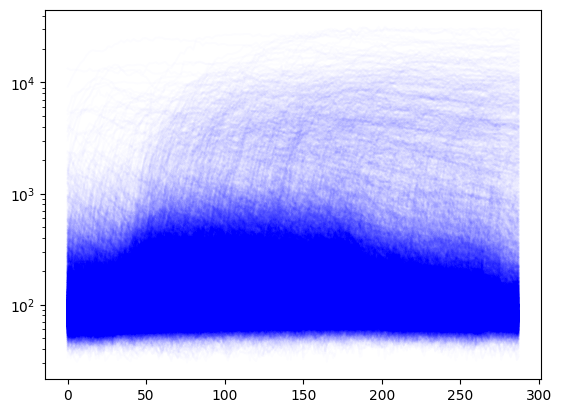

In [5]:
#### import literally everything
# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1'] training set
dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']


# all_data_x=[]
# all_data_y=[]

# for exp_name in dataset_name_list:

#     medium,treatment,replicate = exp_name.split('_')

#     frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
#     size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
#     cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
#     sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
#     mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

#     DeathSubtypes = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])
#     Fates = np.array([i for i in frame.reset_index('fate')['fate']])

#     for i in range(size_array.shape[0]):
#         ##fill nans missing timepoints with the mean of the previous and next timepoints
#         size_serie =  size_array[i]
#         for j in range(1,len(size_serie)-1):
#             if np.isnan(size_serie[j]):
#                 size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

#         sos_serie = sos_array[i]
#         for j in range(1,len(sos_serie)-1):
#             if np.isnan(sos_serie[j]):
#                 sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
#         mcherry_serie = mcherry_array[i]
#         for j in range(1,len(mcherry_serie)-1):
#             if np.isnan(mcherry_serie[j]):
#                 mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

#         cyclefate_serie = cyclefate_array[i]
#         for j in range(len(cyclefate_serie)-1):
#             if cyclefate_serie[j] == 'nan':
#                 cyclefate_serie[j] = cyclefate_serie[j+1]

#         t_death = len(cyclefate_serie)
#         if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
#             t_death = np.where(cyclefate_serie != 'alive')[0][0]

#         # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
#         first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

#         if first_NaN>96:
#             last_usable_timepoint = min(first_NaN,288)
#             all_data_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
#             all_data_y.append((medium,treatment,replicate,t_death,DeathSubtypes[i],Fates[i]))
# #scan for NANs in all all_data_x
# for x in all_data_x:
#     for serie in x:
#         if np.sum(np.isnan(serie))>0:
#             print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',np.array(all_data_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',np.array(all_data_y,dtype=object))
## 1m48

all_data_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',allow_pickle=True)
all_data_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',allow_pickle=True)

index_to_remove =[6,7,8,9,10,18,43,44,45,46,47,2974,2975,2976,3135,3136,3137,3138,3139,3140,3141,3142,3143,3144,3145,5415,5538,5710,5711,5712,5713,5714,5715,5716] #after manual inspection
all_data_x = np.delete(all_data_x, index_to_remove, axis=0)
all_data_y = np.delete(all_data_y, index_to_remove, axis=0)

# pad data with NaNs to make them all the same length, then log and scale then cut them back to original length
max_length = max([x[1].shape[0] for x in all_data_x])
padded_data = np.array([np.pad(x[1], (0, max_length - x[1].shape[0]), mode='constant', constant_values=np.NaN) for x in all_data_x])


padded_data_scaled = TimeSeriesScalerMeanVariance().fit_transform(np.log(padded_data))
padded_data_scaled_minmax = MinMaxScaler(feature_range=(-1, 1)).fit_transform(np.log(padded_data))[:,:,np.newaxis]

data_myscaled = my_scaler([x[1] for x in all_data_x], feature_range=(-1,1))
padded_data_myscaled = np.array([np.pad(x, (0, max_length - x.shape[0]), mode='constant', constant_values=np.NaN) for x in data_myscaled])#[:,:,np.newaxis]

all_data_x_sos_scaled = [padded_data_myscaled[i][:all_data_x[i][1].shape[0]] for i in range(len(all_data_x))]

for s  in  [x[1] for x in all_data_x]:
    plt.plot(s,alpha=0.01,color='blue')
plt.yscale('log')
print('Total dataset size\t',len(all_data_x))
print(all_data_y[0])

In [ ]:
#plot one experiment change timepoints with time
medium,treatment,replicate = 'glu','cip','1'
timescale = np.linspace(0,24,288)
plt.figure(figsize=(10,6))
plt.plot(timescale,np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
plt.yscale('log')
# plt.plot(timescale,np.array([padded_data_scaled_minmax[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
plt.title(f'Unprocessed {medium}_{treatment}_{replicate}', fontsize=16)
plt.xlabel('Time[h]', fontsize=14)
plt.ylabel('Log(SOS Response)', fontsize=14)
plt.tight_layout()
# plt.ylim(0,20000)
# plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
# plt.axvline(x=14, color='red', linestyle='--', linewidth=1)


fig, ax = plt.subplots(1, 3, figsize=(30, 6))
ax[0].plot(timescale,np.array([padded_data_scaled[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
ax[1].plot(timescale,np.array([padded_data_scaled_minmax[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
ax[2].plot(timescale,np.array([padded_data_myscaled[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
ax[0].set_title(f'Log + MeanVariance Scaler', fontsize=16)
ax[1].set_title(f'Log + MinMax Scaler', fontsize=16)
ax[2].set_title(f'Log + Custom Scaler', fontsize=16)


In [6]:
latent_all_trunc = []
all_data_y_trunc = []
vrae_trained.eval()
vrae_trained.batch_size = 1
for i,seq in enumerate([x for x in all_data_x_sos_scaled]): #[x[1] for x in all_data_x]: #
    if seq.shape[0]>=264: #cutting to 264 timepoints (22h) to have all sequences of same length
        seq = seq[:264]
        latent = encode_sequence_1dim(vrae_trained, seq)
        latent_all_trunc.append(latent)
        all_data_y_trunc.append(all_data_y[i])
print(len(all_data_x_sos_scaled))
print('Total dataset size\t',len(all_data_y_trunc))
latent_all = np.array(latent_all_trunc)
all_data_y_trunc = np.array(all_data_y_trunc)

8087
Total dataset size	 7089


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(-15.0, 15.0)

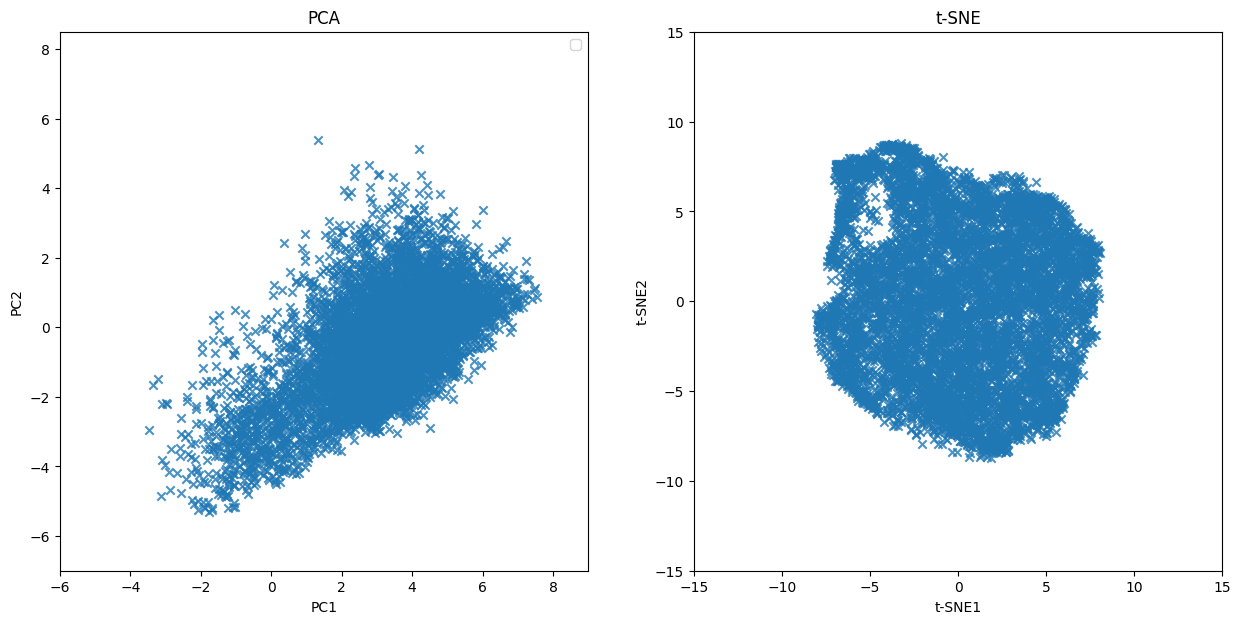

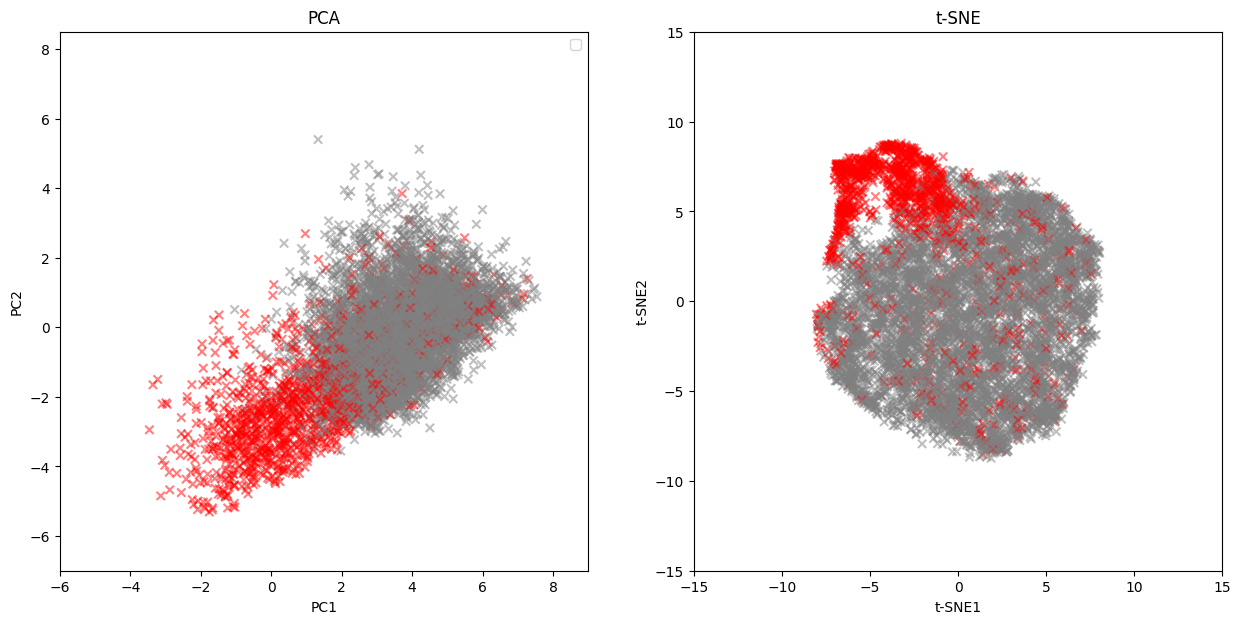

In [14]:
from sklearn.decomposition import TruncatedSVD,PCA
from sklearn.manifold import TSNE

# whole data pca

z_run = latent_all
z_run_pca_fit = TruncatedSVD(n_components=z_run.shape[1]).fit(z_run)
z_run_pca = z_run_pca_fit.transform(z_run)
z_run_tsne = TSNE(perplexity=50, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)

ylims = (-7,8.5)
xlims = (-6,9)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], marker='x',alpha=0.8)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], marker='x',alpha=0.8)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(ylims[0],ylims[1])
ax[0].set_xlim(xlims[0],xlims[1])
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)

hex_colors =  {0:'red', 1:'grey'}
colors = [hex_colors[y[-1]=='survived'] for y in all_data_y_trunc]

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].scatter(z_run_pca[:, 0], z_run_pca[:, 1], color=colors, marker='x',alpha=0.5)
ax[1].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x',alpha=0.5)
ax[0].legend()
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_ylim(ylims[0],ylims[1])
ax[0].set_xlim(xlims[0],xlims[1])
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
ax[1].set_ylim(-15,15)
ax[1].set_xlim(-15,15)



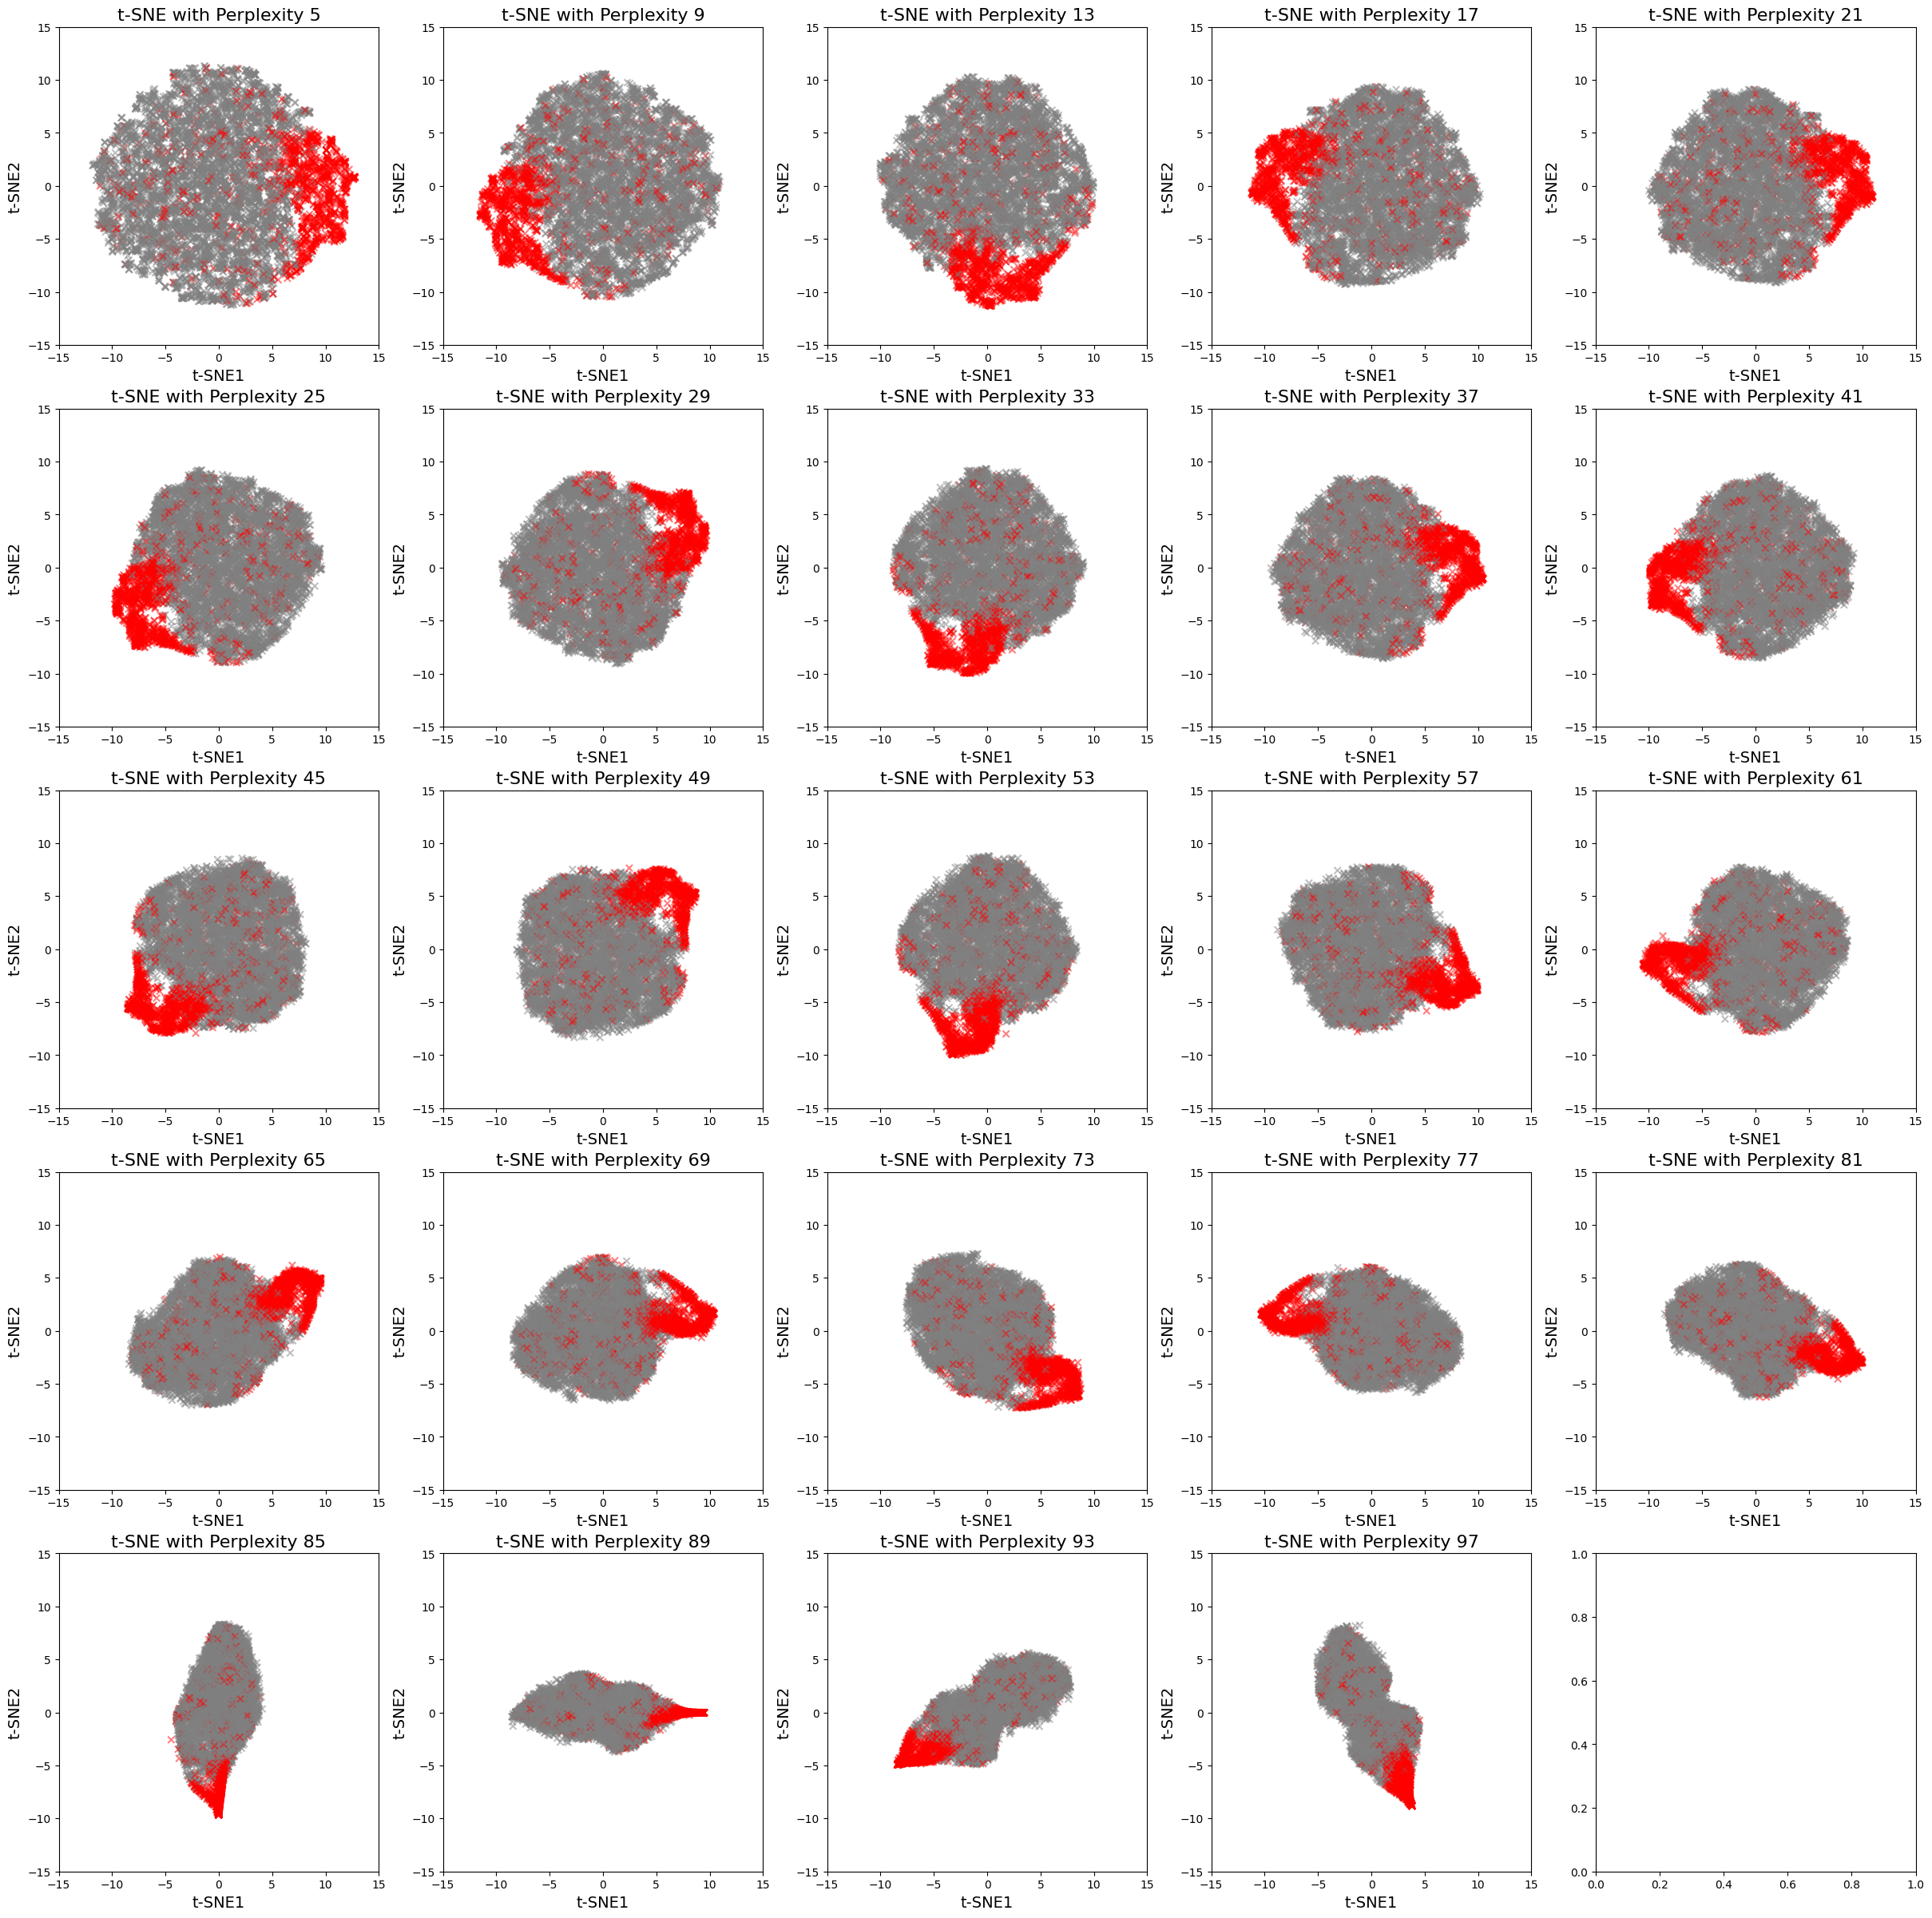

In [13]:
# perplexity grid
perplexities = range(5,100,4)
fig, ax = plt.subplots(5, 5, figsize=(30, 30))
ax = ax.flatten()
for i, perplexity in enumerate(perplexities):
    z_run_tsne = TSNE(perplexity=perplexity, min_grad_norm=1E-12, n_iter=300, learning_rate='auto', init='random').fit_transform(z_run)
    ax[i].scatter(z_run_tsne[:, 0], z_run_tsne[:, 1], color=colors, marker='x', alpha=0.5)
    ax[i].set_title(f't-SNE with Perplexity {perplexity}', fontsize=16)
    ax[i].set_xlabel('t-SNE1', fontsize=14)
    ax[i].set_ylabel('t-SNE2', fontsize=14)
    ax[i].set_ylim(-15, 15)
    ax[i].set_xlim(-15, 15)

[5, 30, 55, 80]